Consideramos el sistema 

$$
\dot x = a (x − b) (x − c)\quad\text{donde}\quad a,b,c\in\mathbb{R}\quad\text{pero} \quad b < c
$$ 

con condicion inicial $x(0) = x_0  \in R$


Grafica el campo de pendientes y el espacio fase. Para cada $x_0$ posible, usa la informacion de estas dos graficas para determinar el comportamiento de las soluciones cuando $t \to \infty$. Considera los casos $a < 0$ , $a = 0$ y $a > 0$ por separado.

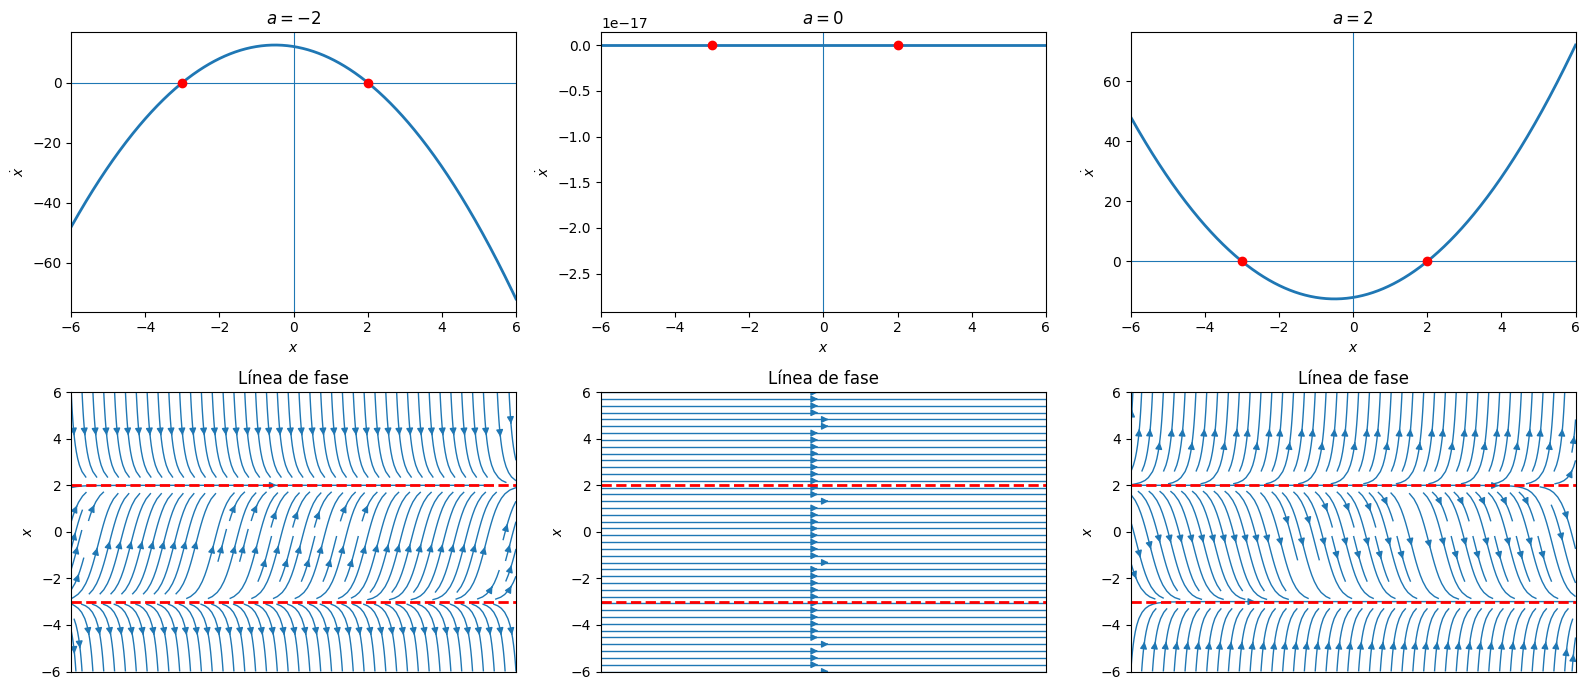

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
a_vals = [-2, 0, 2]
b = -3
c = 2

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for j, a in enumerate(a_vals):

    # =========================
    # Campo de pendientes
    # =========================
    ax1 = axes[0, j]

    x_plot = np.linspace(-6, 6, 600)
    f = a * (x_plot - b) * (x_plot - c)

    ax1.plot(x_plot, f, linewidth=2)
    ax1.axhline(0, linewidth=0.8)
    ax1.axvline(0, linewidth=0.8)
    ax1.plot([b, c], [0, 0], 'ro')

    ax1.set_title(rf"$a = {a}$")
    ax1.set_xlabel("$x$")
    ax1.set_ylabel(r"$\dot x$")
    ax1.set_xlim(-6, 6)


    # =========================
    # Línea de fase (corrientes)
    # =========================
    ax2 = axes[1, j]

    # Mallado en (t, x)
    t = np.linspace(0, 6, 40)
    x = np.linspace(-6, 6, 40)
    T, X = np.meshgrid(t, x)

    # Campo vectorial
    U = np.ones_like(T)                      # dt/ds = 1
    V = a * (X - b) * (X - c)                # dx/ds

    ax2.streamplot(
        T, X, U, V,
        density=1.4,
        linewidth=1,
        arrowsize=1
    )

    # Equilibrios
    ax2.axhline(b, color='red', linestyle='--', linewidth=2)
    ax2.axhline(c, color='red', linestyle='--', linewidth=2)

    ax2.set_xlim(0, 6)
    ax2.set_ylim(-6, 6)
    ax2.set_xticks([])
    ax2.set_ylabel("$x$")
    ax2.set_title("Línea de fase")

plt.tight_layout()
plt.show()


Ahora, Resolvamos la ecuación diferencial de forma exacta (tomando en cuenta las condiciones iniciales) usando fracciones parciales:

Tenemos que: 

$$
\dot{x} = a(x - b)(x - c)
$$ 
de donde, Por separación de variables:

$$
\frac{\dot x}{(x - b)(x - c)} = a
$$

por lo cual :

$$
at 
= a(t-0)=a\int\limits_{0}^{t}dx 
= \int\limits_{0}^{t}adx 
= \int\limits_{0}^{t}\frac{\dot x}{(x - b)(x - c)}dt
$$

pero notamos que:

$$
\frac{1}{(x - b)(x - c)} 
= \frac{1}{b - c} \left( \frac{1}{x - b} - \frac{1}{x - c} \right)
$$

Así:

$$
\frac{\dot x}{(x - b)(x - c)}
= \frac{1}{b - c} \left( \frac{\dot x}{x - b} - \frac{\dot x}{x - c} \right) dx
$$

Integrando:

$$
\int\limits_{0}^{t}\frac{\dot x}{(x - b)(x - c)}dt 
= \frac{1}{b - c} \left( \int\limits_{0}^{t}\frac{\dot x}{x - b}dt - \int\limits_{0}^{t}\frac{\dot x}{x - c}dt \right) 
= \frac{1}{b - c} \int\limits_{0}^{t} \left( \frac{1}{x - b} - \frac{1}{x - c} \right) dx
$$

Por tanto:

$$
at 
= \frac{1}{b - c} \left( \ln \left| \frac{x(t) - b}{x_0 - b} \right| - \ln \left| \frac{x(t) - c}{x_0 - c} \right| \right)
= \frac{1}{b-c}\ln |\frac{(x(t) - b)(x_0 - c)}{(x(t) - c)(x_0 - b)}| 
$$

Es decir: 

$$
at 
= \frac{1}{b-c}\ln |\frac{(x(t) - b)(x_0 - c)}{(x(t) - c)(x_0 - b)}|
$$ 

de donde:

$$
e^{a(b - c)t} 
= \frac{(x(t) - b)(x_0 - c)}{(x(t) - c)(x_0 - b)}
$$

Asi:

$$
\frac{x_0 - b}{x_0 - c}e^{a(b - c)} 
= \frac{x(t) - b}{x(t) - c}
$$

y si tomamos 

$$ M = \frac {x_0 - b}{x_0 - c}e^{a(b - c)t} 
= \frac{x(t) - b}{x(t) - c} 
$$

por lo cual 

$$M(x(t) - c) = x(t) - b$$

Asi:

$$Mx(t) - Mc = x(t) - b$$

$$Mx(t) - x(t) = Mc - b$$

$$x(t)(M - 1) = Mc - b$$

$$x(t) = \frac{Mc - b}{M - 1}$$

Por tanto: 
 
$$ x(t) = \frac{\displaystyle\frac {x_0 - b}{x_0 - c}e^{a(b - c)t}c - b}{\displaystyle\frac {x_0 - b}{x_0 - c}e^{a(b - c)t} - 1}$$

Asi Esto nos dice  que:

-Si $a > 0$, 

$$
\lim\limits_{t \to \infty} = b
$$ 
y Ademas: 

-Si $a < 0$, 

$$
\lim\limits_{t \to \infty} = c
$$















--- 

Considera la ecuación

$$ \dot y = y − 4t + y^2 − 8yt + 16t^2 + 4 $$

En principio este es un sistema bidimensional, ya que parece t de forma explícita en la ecuación. Sin embargo, podemos saber todo acerca de sus soluciones a partir de un sistema unidimensional.

Transformemos esta ecuación diferencial en una ecuación de la forma $ \dot x = f(x)$

usando el cambio de variable 

$$x = y − 4t $$

Es decir 

$$
y = x + 4t 
$$ de donde 

$$
y^2 = (x+4t)^2 = x^2 + 8xt + 16t^2
$$

Ademas, notemos que 
$$
\dot y = \dot x + 4
$$

asi tenemos que:

$$
\dot y 
= y - 4t + y^2 - 8yt + 16t^2 + 4 
= x + (x^2 + 8xt + 16t^2) - 8t(x + 4t) + 16t^2 + 4 
= x + x^2 + 4$$

por tanto:

$$
\dot x + 4 
= \dot y 
= x + x^2 + 4
$$

de donde, 
$$
\dot x = x + x^2
$$


Encontremos ahora las soluciones de equilibrio de este nuevo sistema y veamos sus estabilidades

Como 
$$
\dot x = x + x^2 = x(1+x)
$$

entonces 

$$
x_{1}^{*} = 0\quad\text{y}\quad x_{2}^{*} = -1
$$

son las soluciones de equilibrio

Por otro lado, como 

$$
f(x) = x + x^2
$$

$$
f´(x) = 1 + 2x
$$

asi:

$$f´(0) = 1 > 0$$

$$
f´(-1) = 1-2 = -1<0
$$

por lo cual 

$$
x_1^{*}=0\quad\text{es inestable}
$$

$$
x_2^{*} = -1 \quad\text{es estable}
$$

Con estas soluciones de quilibrio, podemos calcular las soluciones de equilibrio del sistema de $y$

De donde 
$$
0 = x_1^{*}(t) = y_1^{*}(t) - 4t
$$

Es decir

$$
y_1^{*}(t) = 4t
$$ 

y ademas

$$
-1 = x_2^{*}(t) = y_2^{*}(t) - 4t
$$

Entonces 
$$
y_2^{*}(t) = 4t - 1
$$

Por lo tanto 
$$
y_1^{*}(t) = 4t, \quad y_2^{*}(t) = 4t - 1
$$

son las soluciones de equilibrio  del sistema $y$

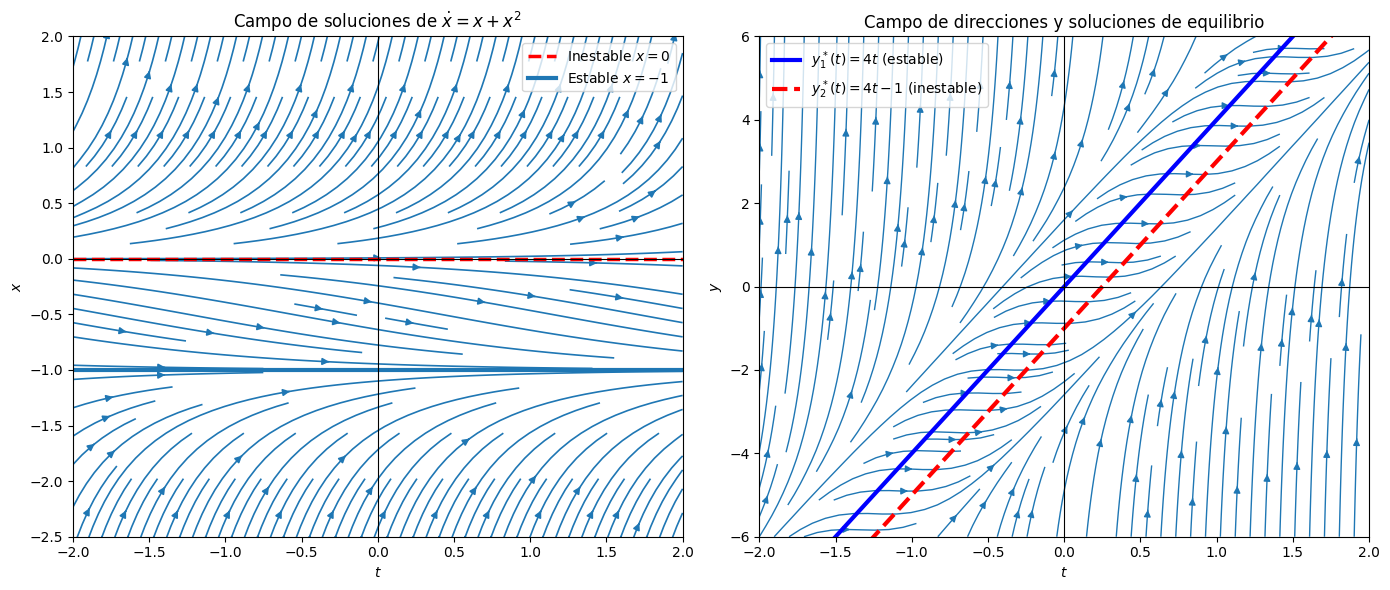

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FIGURA CON DOS SUBGRÁFICAS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================================
# GRÁFICA 1:  ẋ = x + x²
# ============================================================

# Dominio
t = np.linspace(-2, 2, 400)
x = np.linspace(-3, 3, 400)
T, X = np.meshgrid(t, x)

# Campo vectorial
U = np.ones_like(X)
V = X + X**2

ax = axes[0]

ax.streamplot(
    T, X, U, V,
    density=1.6,
    color='#1f77b4',
    linewidth=1.2,
    arrowsize=1
)

# Soluciones de equilibrio
t_plot = np.linspace(-2, 2, 400)

ax.plot(t_plot, np.zeros_like(t_plot),
        'r--', linewidth=2.5, label='Inestable $x=0$')

ax.plot(t_plot, -np.ones_like(t_plot),
        color='#1f77b4', linewidth=3, label='Estable $x=-1$')

# Ejes
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlim(-2, 2)
ax.set_ylim(-2.5, 2)
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")
ax.set_title(r"Campo de soluciones de $\dot x = x + x^2$")
ax.legend()


# ============================================================
# GRÁFICA 2:  ẏ = (y − 4t)² + (y − 4t)
# ============================================================

def f(t, y):
    return (y - 4*t)**2 + (y - 4*t)

# Dominio
t = np.linspace(-2, 2, 30)
y = np.linspace(-6, 6, 30)
T, Y = np.meshgrid(t, y)

DT = np.ones_like(T)
DY = f(T, Y)

# Normalización
norm = np.sqrt(DT**2 + DY**2)
DT /= norm
DY /= norm

ax = axes[1]

ax.streamplot(
    T, Y, DT, DY,
    density=1.4,
    linewidth=1,
    arrowsize=1
)

# Soluciones de equilibrio
t_plot = np.linspace(-2, 2, 400)
y1 = 4*t_plot
y2 = 4*t_plot - 1

ax.plot(t_plot, y1, color='blue', linewidth=3,
        label=r'$y_1^*(t)=4t$ (estable)')

ax.plot(t_plot, y2, 'r--', linewidth=3,
        label=r'$y_2^*(t)=4t-1$ (inestable)')

# Ejes
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlim(-2, 2)
ax.set_ylim(-6, 6)
ax.set_xlabel("$t$")
ax.set_ylabel("$y$")
ax.set_title("Campo de direcciones y soluciones de equilibrio")
ax.legend()


# ============================================================
plt.tight_layout()
plt.show()
